# # Frontal (AP) Lumbar L4 **Segmentation (Mask) + Bone Density Measurement** — BUU-LSPINE + YOLOv8-seg

Instead of boxes, a **pixel mask** is used to select only the L4 vertebral body region, and the bone density index is calculated using the pixel values ​​within it.

Key Point: The L4 label in BUU-LSPINE is the **4 corner points (left/right of the upper and lower endplates)** → These 4 points form the vertebral body rectangular polygon.  
Training **YOLOv8-seg** with this polygon yields a mask without separate segmentation labels.  

> ⚠️   
> Bone Density Caution: Values ​​obtained from standard X-rays (planar images) are **uncorrected 'radiological density (pixel values)' proxies**.   
> True BMD (g/cm²) requires DXA/QCT or **correction references** within the image, such as aluminum step wedges.  
> To compare patients, identical imaging conditions or correction criteria are required (see No. 7 below).  


## 0. Installation & Import

In [11]:
# !pip install ultralytics pydicom pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg opencv-python-headless
import os, glob, re, random, shutil, csv
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


## 1. Path / Settings

In [12]:
BUU_AP_IMAGES = "./BUU-LSPINE-2000/AP/images"
BUU_AP_LABELS = "./BUU-LSPINE-2000/AP/labels"

YOLO_ROOT = "./yolo_ap_seg"
VAL_RATIO = 0.15
SEED = 42

CLASS_NAMES = ["L1","L2","L3","L4","L5"]
L4_CLASS_ID = CLASS_NAMES.index("L4")
LINES_PER_VERTEBRA = 2          # 상/하 종판
N_VERTEBRAE = 5
random.seed(SEED)
print("L4 class id =", L4_CLASS_ID)

L4 class id = 3


## 2. Label check (run first)
Print one actual label to verify the format. (Assumption: 10 lines, each line `xL yL xR yR`, 2 consecutive lines = one vertebra)

In [ ]:
lbls = sorted(glob.glob(os.path.join(BUU_AP_LABELS, "*")))
print("Number of labels:", len(lbls))
if lbls:
    print("예시:", lbls[0], "\n----- 내용 -----")
    print(open(lbls[0]).read())

라벨 수: 2000
예시: ./BUU-LSPINE-2000/AP/labels\0001-F-037Y0.csv 
----- 내용 -----
876.2222,167.0618,1111.472,168.7665,0
865.9939,313.6671,1119.996,313.6671,0
870.8508,344.4474,1116.587,351.1707,0
847.6437,498.0999,1119.997,511.2078,0
842.3262,553.4754,1108.814,557.2025,0
825.0808,705.7509,1118.291,724.5027,0
826.1249,774.749,1111.775,787.0792,5
801.4645,937.0969,1113.83,957.6473,0
797.71,983.067,1115.284,980.1932,0
766.5613,1163.979,1129.421,1157.696,0



## 3. Label → YOLO-seg Polygon Transformation
Create polygons by aligning the 4 corner points of each vertebra in a **clockwise direction (TL→TR→BR→BL)**.

Assign classes L1..L5 from top to bottom by aligning the 5 vertebrae by y (file order does not matter).

In [ ]:
def _rows(path):
    out=[]
    for line in open(path):
        nums = re.findall(r"-?\d+\.?\d*", line)
        if len(nums) >= 4:
            out.append([float(v) for v in nums[:4]])  # xL,yL,xR,yR
    return out

def order_quad(pts):
    """4점 -> [TL,TR,BR,BL] (Clockwise, non-intersecting square)"""
    pts = sorted(pts, key=lambda p: p[1])          # Sort by y
    top = sorted(pts[:2], key=lambda p: p[0])      # Top 2 points: Left, Right
    bot = sorted(pts[2:], key=lambda p: p[0])      # Bottom 2 points: Left, Right
    return [top[0], top[1], bot[1], bot[0]]

def parse_polys(path):
    """-> List of [Polygons (4 points)] in L1..L5 order. [] on failure"""
    rows = _rows(path)
    if len(rows) < LINES_PER_VERTEBRA * N_VERTEBRAE:
        return []
    verts=[]
    for i in range(N_VERTEBRAE):
        pts=[]
        for j in range(LINES_PER_VERTEBRA):
            xL,yL,xR,yR = rows[i*LINES_PER_VERTEBRA + j]
            pts += [(xL,yL),(xR,yR)]
        quad = order_quad(pts)
        cy = sum(p[1] for p in quad)/4
        verts.append((cy, quad))
    verts.sort(key=lambda v: v[0])                 # Up -> Down
    return [q for _,q in verts]

def seg_line(cls_id, quad, W, H):
    coords=[]
    for x,y in quad:
        coords += [f"{x/W:.6f}", f"{y/H:.6f}"]
    return f"{cls_id} " + " ".join(coords)

def find_image(stem):
    for ext in (".jpg",".jpeg",".png",".JPG",".PNG"):
        p=os.path.join(BUU_AP_IMAGES, stem+ext)
        if os.path.exists(p): return p
    return None

for sub in ["images/train","images/val","labels/train","labels/val"]:
    os.makedirs(os.path.join(YOLO_ROOT, sub), exist_ok=True)

label_files = sorted(glob.glob(os.path.join(BUU_AP_LABELS,"*")))
random.shuffle(label_files)
n_val = int(len(label_files)*VAL_RATIO)
ok=skip=0
for k,lp in enumerate(label_files):
    stem=os.path.splitext(os.path.basename(lp))[0]
    ip=find_image(stem)
    if ip is None: skip+=1; continue
    polys=parse_polys(lp)
    if len(polys)!=N_VERTEBRAE: skip+=1; continue
    im=cv2.imread(ip); H,W=im.shape[:2]
    split="val" if k<n_val else "train"
    shutil.copy(ip, os.path.join(YOLO_ROOT,"images",split,os.path.basename(ip)))
    with open(os.path.join(YOLO_ROOT,"labels",split,stem+".txt"),"w") as f:
        for cid,quad in enumerate(polys):
            f.write(seg_line(cid,quad,W,H)+"\n")
    ok+=1
print(f"변환: {ok}장, 건너뜀 {skip}장 (val {n_val})")

변환: 2000장, 건너뜀 0장 (val 300)


## 3b. (Optional) Transformation Validation — Check if the polygon is properly placed on the vertebrae

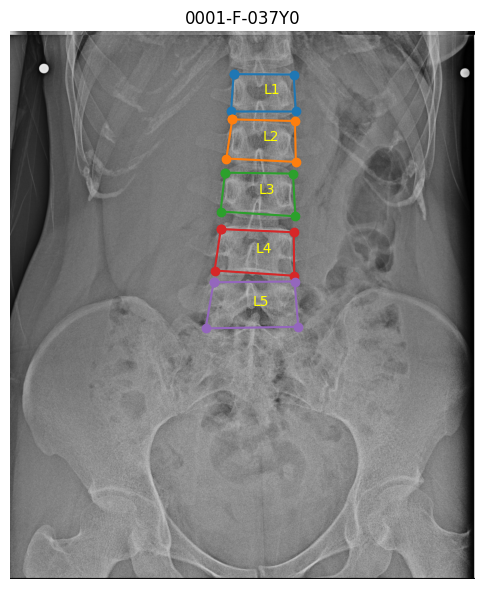

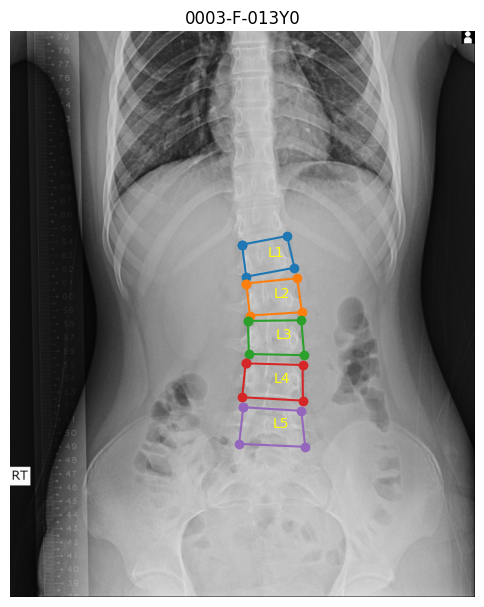

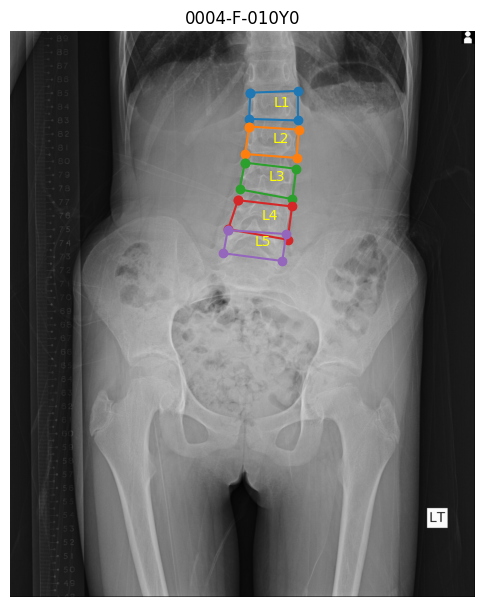

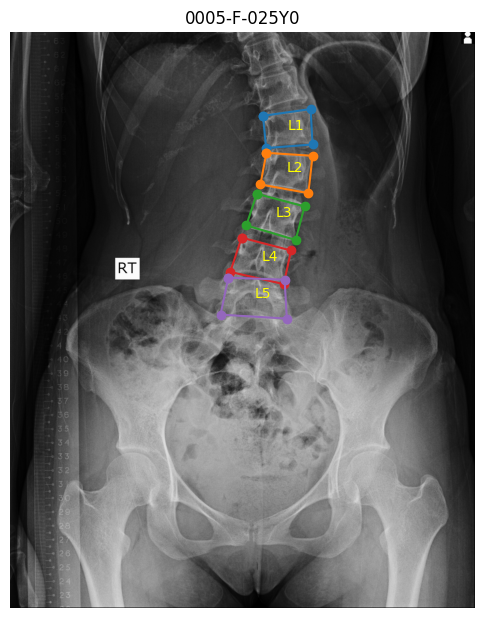

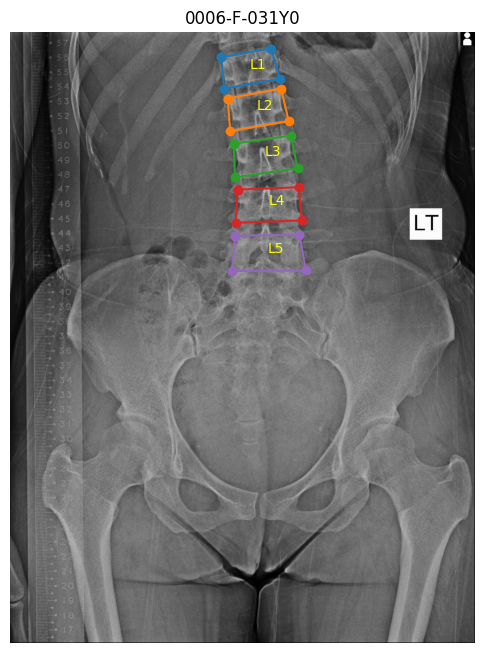

In [ ]:
VIEW_RANGE = slice(0, 5)  # Current setting: Check a total of 5 items from the 0th to just before the 5th.
all_samples = sorted(glob.glob(os.path.join(YOLO_ROOT, "images", "train", "*")))
samples = all_samples[VIEW_RANGE]
for ip in samples:
    stem = os.path.splitext(os.path.basename(ip))[0]
    im = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
    H, W = im.shape[:2]
    
    plt.figure(figsize=(6, 9))
    plt.imshow(im)
    
    # Reading and drawing the label file for the image
    label_path = os.path.join(YOLO_ROOT, "labels", "train", stem + ".txt")
    if os.path.exists(label_path): # Added a safety mechanism for cases where the label file is missing
        for line in open(label_path):
            p = line.split()
            cid = int(p[0])
            xy = np.array(p[1:], float).reshape(-1, 2) * [W, H]
            plt.plot(*np.vstack([xy, xy[0]]).T, "-o", lw=1.5)
            plt.text(xy[:, 0].mean(), xy[:, 1].mean(), CLASS_NAMES[cid], color="yellow")
            
    plt.axis("off")
    plt.title(stem)
    plt.show()

## 4. data.yaml

In [6]:
yaml_path=os.path.join(YOLO_ROOT,"data.yaml")
with open(yaml_path,"w") as f:
    f.write(f"path: {os.path.abspath(YOLO_ROOT)}\n")
    f.write("train: images/train\nval: images/val\n")
    f.write(f"nc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n")
print(open(yaml_path).read())

path: c:\Users\csm02\Desktop\edward\bmd\1 src\yolo_ap_seg
train: images/train
val: images/val
nc: 5
names: ['L1', 'L2', 'L3', 'L4', 'L5']



## 5. YOLOv8-seg training
The mask will only appear if it is the `-seg` model.

In [ ]:
#from ultralytics import YOLO
#model = YOLO("yolov8n-seg.pt")        # More accurately: yolov8s-seg.pt
#results = model.train(data=yaml_path, 
#            epochs=100, 
#            imgsz=640, 
#            batch=-1,
#            project="ap_seg", 
#            name="l1_l5", 
#            patience=20,
#            cache=True,
#            workers=0)
#BEST="./ap_seg/l1_l5/weights/best.pt"
#print("best ->", BEST)

New https://pypi.org/project/ultralytics/8.4.68 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.60  Python-3.12.13 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_ap_seg\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mo

## 6. DICOM Inference → L4 **Mask** + Bone Density Measurement
- The model infers from normalized RGB, and **bone density is measured from the original (rescaled) pixel values**.
- MONOCHROME1 is unified in the direction of 'bright bone' (higher values ​​indicate higher density).
- `ROI_SHRINK`: To view only the **central cancellous bone** while avoiding the endplate/cortex, shrink the polygon towards the center (e.g., 0.7).

[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=372px mean=14158.2 median=14188.5
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=494px mean=14324.2 median=14303.5
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=405px mean=13247.7 median=13241.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=218px mean=13537.5 median=13654.0


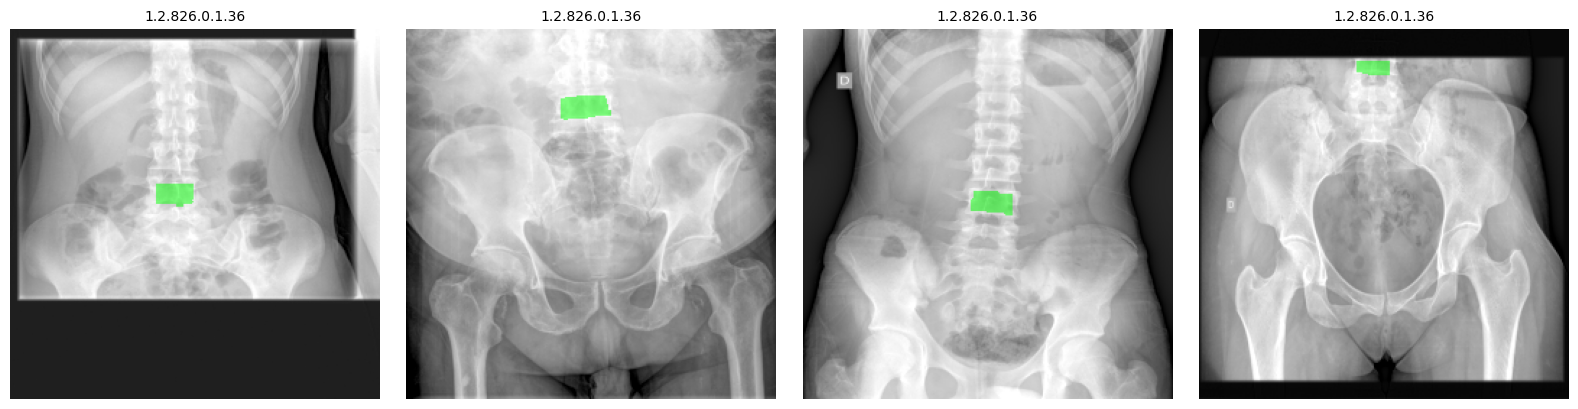

[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=370px mean=12936.9 median=13043.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=411px mean=13173.1 median=13260.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=448px mean=12853.8 median=12931.5
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=421px mean=11182.7 median=11171.0


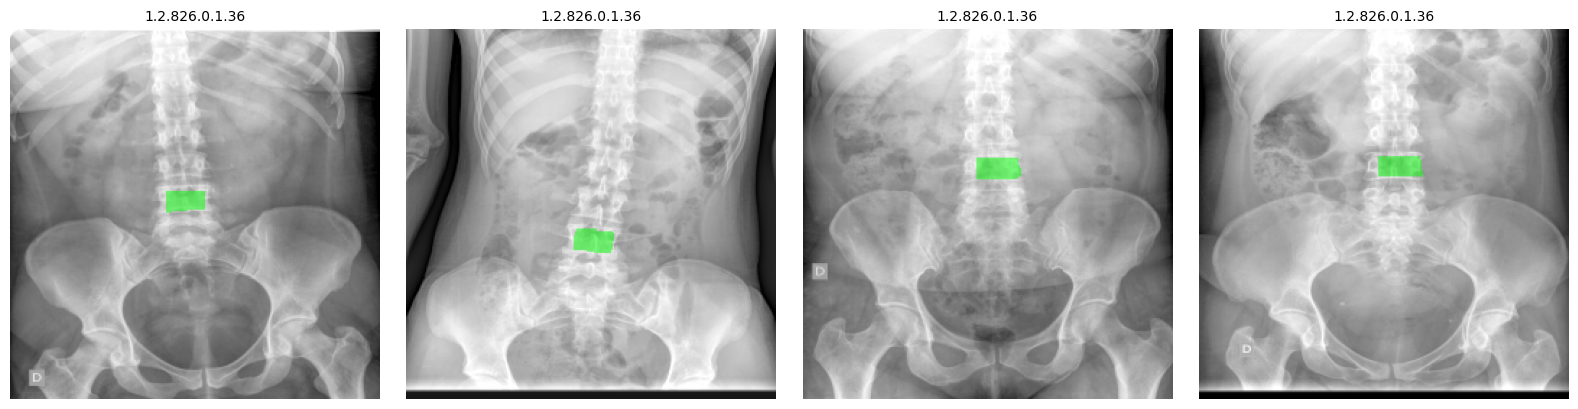

[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=248px mean=12156.3 median=12161.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=375px mean=12036.9 median=12152.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=504px mean=11765.0 median=11842.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=567px mean=11665.1 median=11698.0


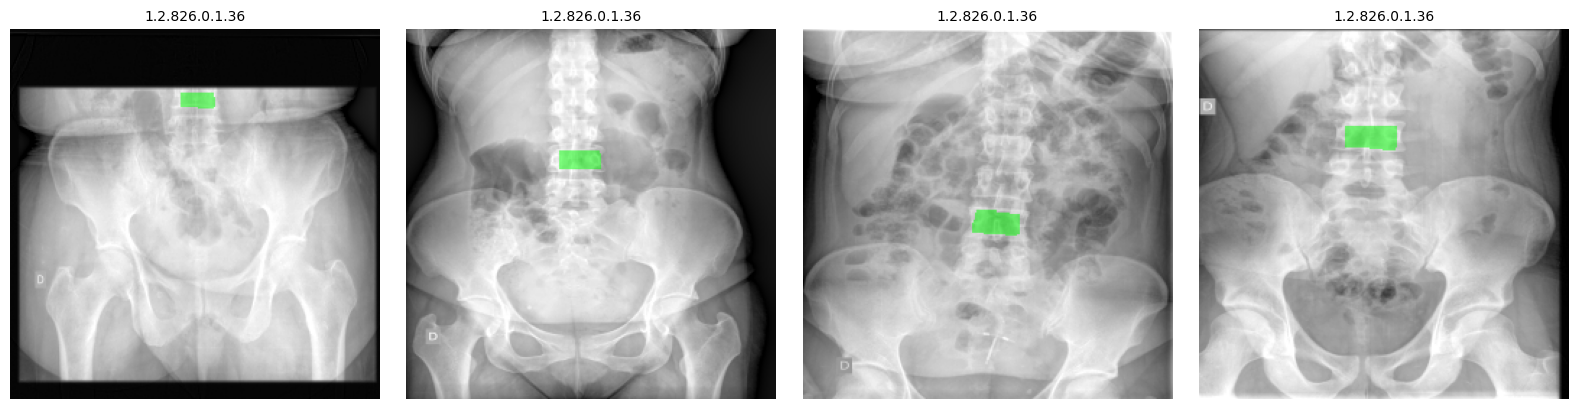

[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=414px mean=12641.4 median=12705.5
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=513px mean=12090.6 median=12248.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=332px mean=14448.5 median=14519.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=491px mean=9790.4 median=9514.0


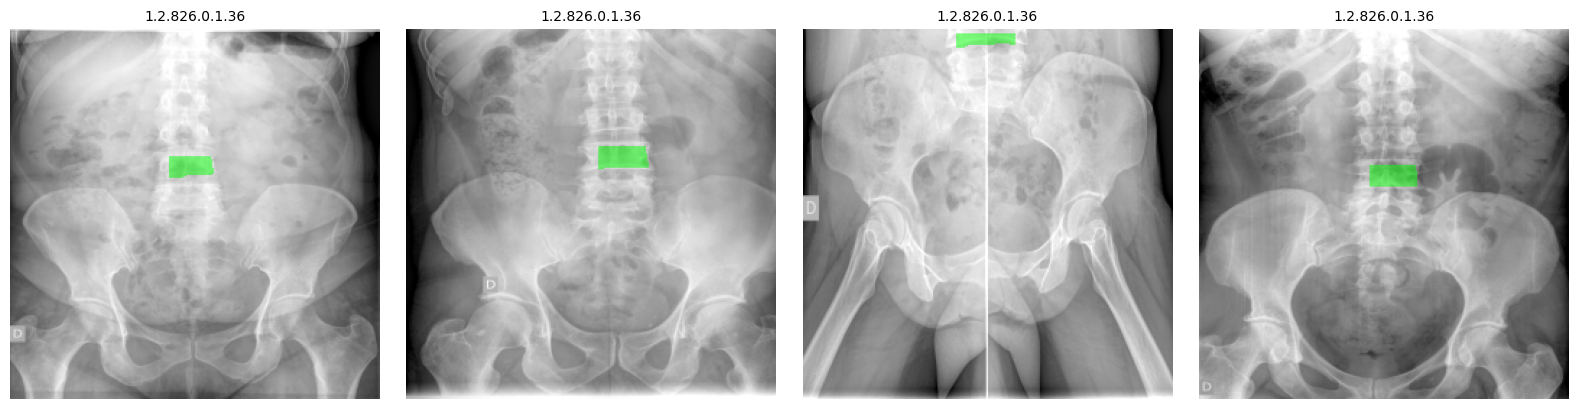

[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=421px mean=13035.5 median=13144.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=493px mean=11202.9 median=11275.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=526px mean=12653.1 median=12657.5
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=491px mean=11225.3 median=11197.0


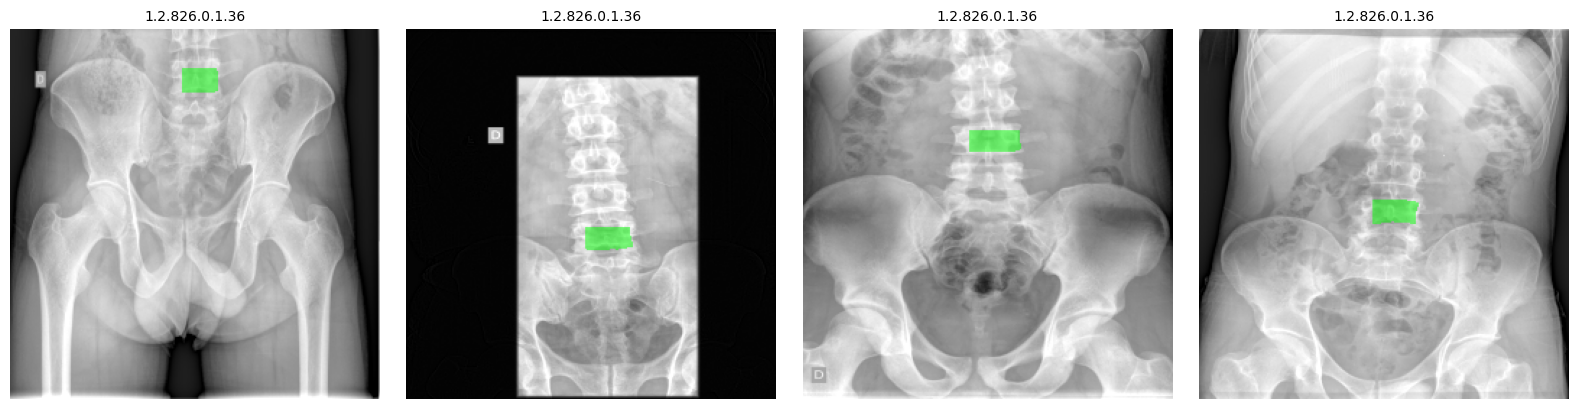

[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=457px mean=13557.2 median=13436.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=455px mean=12193.8 median=12224.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=518px mean=13262.7 median=13279.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=508px mean=12644.5 median=12713.5


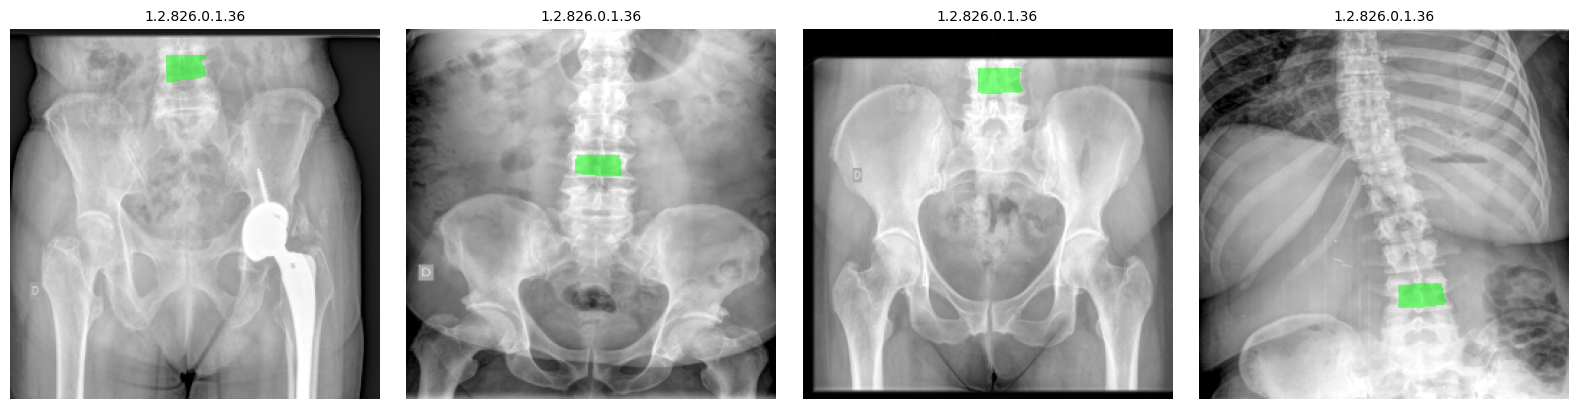

[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=379px mean=11748.6 median=11865.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=529px mean=14478.0 median=14506.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=423px mean=12519.5 median=12498.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=401px mean=13384.9 median=13451.0


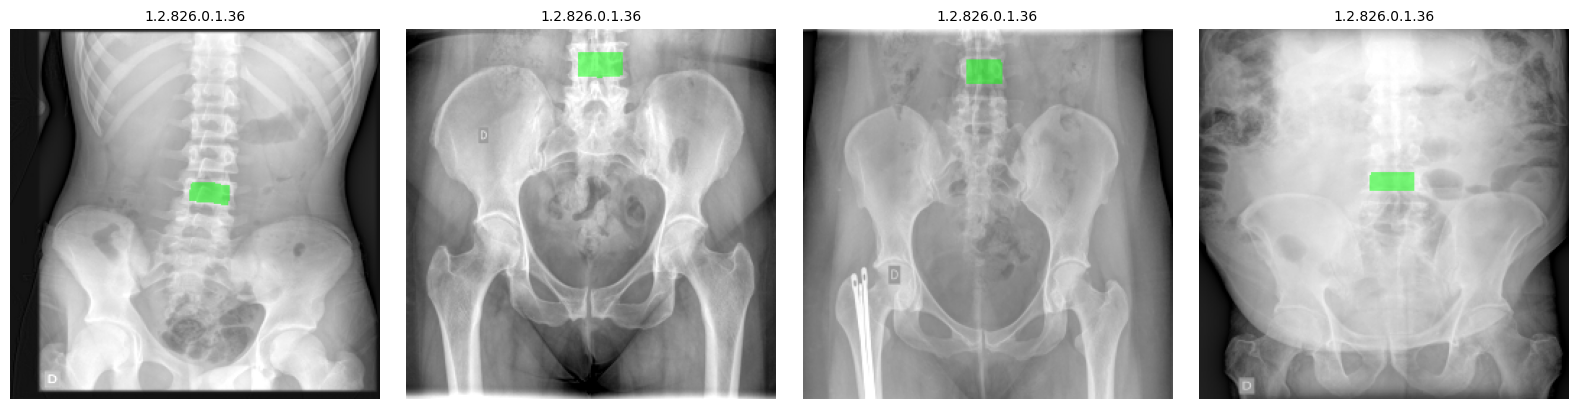

[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=348px mean=14443.6 median=14462.5
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=403px mean=11831.4 median=11800.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=382px mean=12538.4 median=12513.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=514px mean=12530.8 median=12612.5


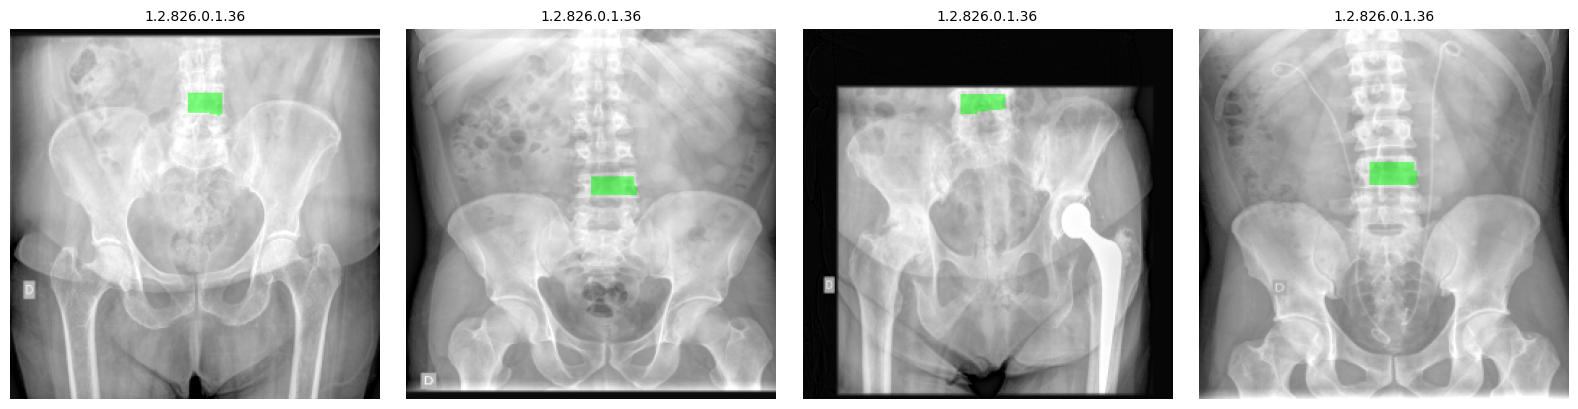

[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=416px mean=12406.9 median=12391.0
[skip] 1.2.826.0.1.36: 척추체 1개뿐
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=502px mean=12570.2 median=12583.5
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=437px mean=11071.0 median=11006.0
[skip] 1.2.826.0.1.36: 척추체 1개뿐
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=480px mean=12258.7 median=12365.0


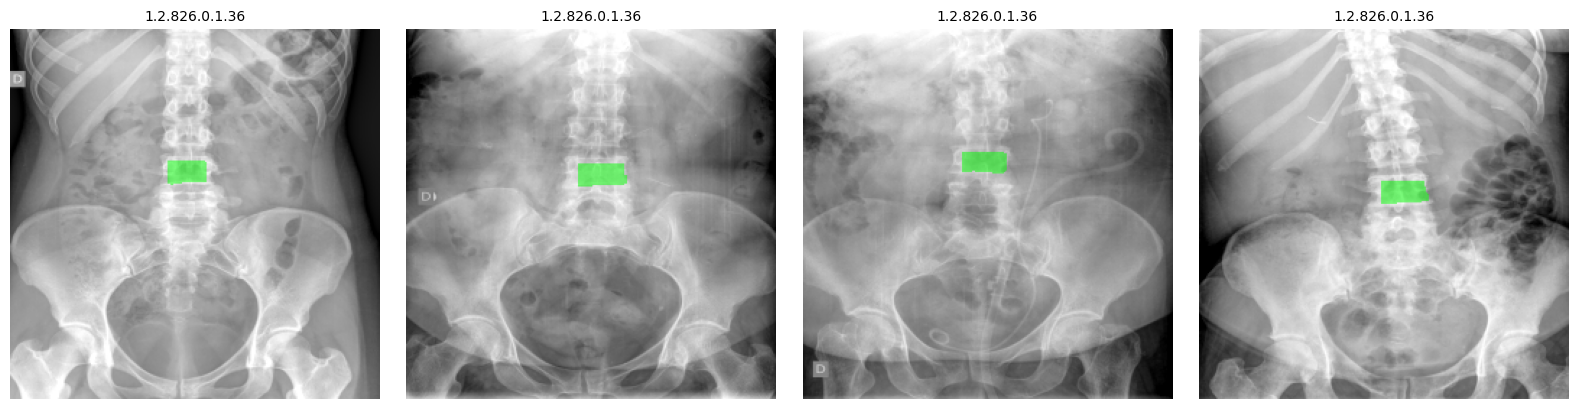

[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=367px mean=10346.3 median=10304.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=519px mean=12386.0 median=12434.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=473px mean=11726.1 median=11789.0
[ ok ] 1.2.826.0.1.36: L4 클래스 직접 | area=429px mean=12310.1 median=12414.0


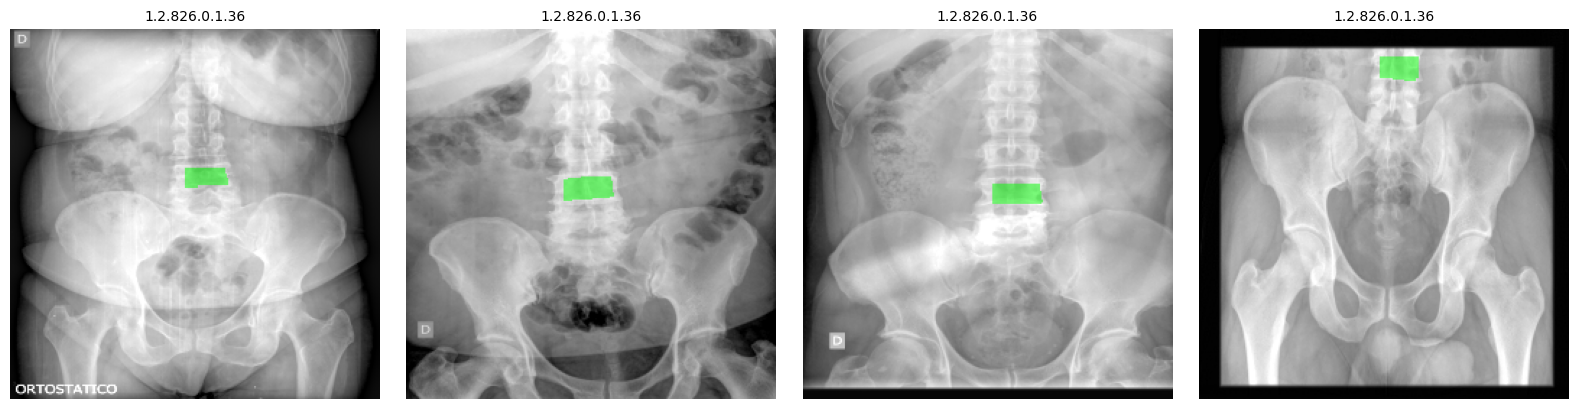


완료. L4 마스크/밀도 40건, 실패 2건 -> ./l4_seg_output (L4_density.csv)


In [ ]:
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut

DICOM_DIR = "./dataset-dcm/train/gather/"
OUT_DIR   = "./l4_seg_output"
BEST = r"C:\Users\csm02\Desktop\edward\bmd\1 src\runs\segment\ap_seg\l1_l5\weights\best.pt" #os.path.join(results.save_dir, "weights", "best.pt")         
INVERT    = True        # Match to the same tone as the training image (brighten bones)
CONF      = 0.25
ROI_SHRINK = 0.7        # 1.0=Whole vertebral body, 0.7=Central cancellous bone ROI

os.makedirs(OUT_DIR, exist_ok=True)
seg = YOLO(BEST)

def load_dicom(path):
    """Returns: (model_rgb[uint8, "Bone Brightness"], density_arr[float, "Bone Brightness", "Rescale only"], H, W)"""
    ds=pydicom.dcmread(path)
    raw=ds.pixel_array.astype(np.float32)
    raw=raw*float(getattr(ds,"RescaleSlope",1.0))+float(getattr(ds,"RescaleIntercept",0.0))
    mono1 = str(getattr(ds,"PhotometricInterpretation","")).upper()=="MONOCHROME1"
    # For density: Standardize only the direction so that higher values ​​result in higher density (no percentile clips to preserve linearity)
    dens = (raw.max()-raw) if mono1 else raw.copy()
    # For model input: Good-looking 8-bit
    a=raw.copy()
    if INVERT and mono1: a=a.max()-a
    lo,hi=np.percentile(a,0.5),np.percentile(a,99.5)
    if hi<=lo: lo,hi=a.min(),a.max()+1e-6
    rgb=cv2.cvtColor((np.clip((a-lo)/(hi-lo),0,1)*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
    H,W=raw.shape
    return rgb, dens, H, W

def poly_to_mask(poly_xy, H, W, shrink=1.0):
    poly=np.asarray(poly_xy,dtype=np.float32)
    if shrink!=1.0 and len(poly):
        ctr=poly.mean(0); poly=ctr+shrink*(poly-ctr)
    m=np.zeros((H,W),np.uint8)
    cv2.fillPoly(m,[poly.astype(np.int32)],1)
    return m

def pick_l4_index(boxes_xyxy, classes, confs):
    if len(boxes_xyxy)==0: return None,"No detection"
    idx=[i for i,c in enumerate(classes) if c==L4_CLASS_ID]
    if idx: return max(idx,key=lambda i:confs[i]),"L4 class direct"
    order=sorted(range(len(boxes_xyxy)),key=lambda i:(boxes_xyxy[i][1]+boxes_xyxy[i][3])/2)
    if len(order)>=4: return order[3],"Top -> Bottom 4th (Fallback)"
    return None,f"vertebrae: Only {len(boxes_xyxy)}"

rows=[["file","status","area_px","mean","median","std","p10","p90"]]
okN=failN=0

vis_list = []
dcm_files = sorted(glob.glob(os.path.join(DICOM_DIR, "*.dcm")))
for idx, path in enumerate(dcm_files):
    stem=os.path.splitext(os.path.basename(path))[0]
    try:
        rgb,dens,H,W=load_dicom(path)
        r = seg.predict(rgb, conf=CONF, verbose=False)[0]
        if r.masks is None or len(r.boxes)==0:
            print(f"[skip] {stem[:14]}: No detection"); rows.append([stem,"No detection",0,0,0,0,0,0]); failN+=1; continue
        boxes=r.boxes.xyxy.cpu().numpy(); classes=r.boxes.cls.cpu().numpy().astype(int); confs=r.boxes.conf.cpu().numpy()
        i,status=pick_l4_index(boxes,classes,confs)
        if i is None:
            print(f"[skip] {stem[:14]}: {status}"); rows.append([stem,status,0,0,0,0,0,0]); failN+=1; continue
        mask=poly_to_mask(r.masks.xy[i],H,W,shrink=ROI_SHRINK)   # Original resolution polygon
        vals=dens[mask>0]
        if vals.size==0:
            print(f"[skip] {stem[:14]}: Empty mask"); failN+=1; continue
        stat=dict(area=int(vals.size), mean=float(vals.mean()), median=float(np.median(vals)),
                  std=float(vals.std()), p10=float(np.percentile(vals,10)), p90=float(np.percentile(vals,90)))
        np.save(os.path.join(OUT_DIR,f"{stem}_L4_mask.npy"), mask)
        vis=rgb.copy(); vis[mask>0]=(0.5*vis[mask>0]+0.5*np.array([0,255,0])).astype(np.uint8)
        cv2.imwrite(os.path.join(OUT_DIR,f"{stem}_L4_segoverlay.png"), cv2.cvtColor(vis,cv2.COLOR_RGB2BGR))
        rows.append([stem,status,stat["area"],round(stat["mean"],2),round(stat["median"],2),
                     round(stat["std"],2),round(stat["p10"],2),round(stat["p90"],2)])
        print(f"[ ok ] {stem[:14]}: {status} | area={stat['area']}px mean={stat['mean']:.1f} median={stat['median']:.1f}")
        # ---------- visualization ----------
        vis_list.append((vis, f"{stem[:14]}"))
        
        if len(vis_list) == 4 or idx == len(dcm_files) - 1:
            num_imgs = len(vis_list)
            # ------------------- Visualization ---------------------------
            fig, axes = plt.subplots(1, 4, figsize=(16, 4))
            
            axes = np.atleast_1d(axes).flatten()
                
            for k in range(4):
                if k < num_imgs:
                    axes[k].imshow(vis_list[k][0])
                    axes[k].set_title(vis_list[k][1], fontsize=10)
                    axes[k].axis('off')
                else:
                    axes[k].axis('off')
            plt.tight_layout()
            plt.show()
            plt.close(fig)
            vis_list = []
            # --------------------------------------------------------------
        okN+=1
        pass
    except Exception as e:
        print(f"[fail] {stem[:14]}: {e}"); failN+=1

with open(os.path.join(OUT_DIR,"L4_density.csv"),"w",newline="") as f:
    csv.writer(f).writerows(rows)
print(f"\ncomplete. L4 Mask/Density {okN} cases, fail {failN} cases -> {OUT_DIR} (L4_density.csv)")

## 7. To increase the accuracy of bone density measurement (important)
Currently, `mean/median` is merely the **average pixel value of the L4 region**, not the corrected BMD. To improve accuracy:

1. **Correction Reference (Nearly Essential)**: When shooting, capture a reference object such as an aluminum step wedge,  
and convert the spine pixel values ​​into the aluminum equivalent thickness (mmAl) using that step-by-step pixel value↔th thickness curve.  
2. **Internal Reference Normalization (Suboptimal)**: Divided by the average of the soft tissue ROIs in the same image  
Corrects differences in exposure between shots → Enables relative comparison between patients. (Additional detection of soft tissue ROIs is required)  
3. **Central Cancellous Bone ROI**: Measure only the center, avoiding the endplate and cortex, as in `ROI_SHRINK=0.7` (close to clinical BMD practice).  
4. **Raw Value Consistency**: Apply only rescale and do not use percentile clipping for measurement (applied to this notebook).  
   If possible, use raw/for-processing DICOM and do not mix processed (LUT applied) images.  
5. **Mask Quality**: Check if the polygon fits well on the end plate with 3b cells. If more precise outlines are needed,  
you can fine-tune by creating manual segmentation labels on the minority images, or refine the contours using a detection box + SAM.  